---
date: "2026-04-04"
date-modified: last-modified
format:
  html:
    toc: true
---

# The Axiom of Completeness

## 1\. The Axiom of Completeness

**Definition:** The Axiom of Completeness (AoC) states that every non-empty set of real numbers that is bounded above has a [least upper bound](https://www.google.com/search?q=supremum-infimum.ipynb) (supremum) in $\mathbb{R}$.

## 2\. Proposition: $\mathbb{Q}$ is Incomplete

To demonstrate why we must construct $\mathbb{R}$, we first prove that the field of rational numbers $\mathbb{Q}$ fails the Axiom of Completeness.

**Given:** The set $S = \{x \in \mathbb{Q} \mid x > 0 \text{ and } x^2 < 2\}$.

**Goal:** Show that $S$ has the prerequisites for the AoC (non-empty, bounded above in $\mathbb{Q}$), but lacks a supremum in $\mathbb{Q}$.

**Proof:**

**Step 1: $S$ is non-empty and bounded above.**

  * **Non-empty:** Since $1 \in \mathbb{Q}$, $1 > 0$, and $1^2 = 1 < 2$, it follows that $1 \in S$. Thus, $S \neq \emptyset$.
  * **Bounded Above:** We claim $2$ is an upper bound. We must show that if $a \in S$, then $a \leq 2$. Alternatively, by [contrapositive](pre-logic.ipynb), if $a > 2$, then $a \notin S$.
    Assume $a \in \mathbb{Q}$ and $a > 2$. Since $a > 2 > 0$, we have $a^2 > 2^2 = 4 > 2$. Because $a^2 > 2$, $a \notin S$. Therefore, $2$ is a valid upper bound for $S$.

**Step 2: $S$ has no least upper bound in $\mathbb{Q}$.**

Suppose, for the sake of contradiction, that $S$ has a supremum $p \in \mathbb{Q}$. We know that $p^2 \neq 2$ because $\sqrt{2} \notin \mathbb{Q}$. Therefore, we must consider two cases: $p^2 < 2$ and $p^2 > 2$.

We define a new rational number $q$:
$$q = p - \frac{p^2-2}{p+2} = \frac{p(p+2) - (p^2-2)}{p+2} = \frac{2p+2}{p+2}$$

By basic algebra, we calculate $q^2 - 2$:
$$q^2 - 2 = \left(\frac{2p+2}{p+2}\right)^2 - 2 = \frac{4p^2+8p+4 - 2(p^2+4p+4)}{(p+2)^2} = \frac{2p^2-4}{(p+2)^2} = \frac{2(p^2-2)}{(p+2)^2}$$

  * **Case 1: $p^2 < 2$.**

    
    If $p^2 < 2$, then $p^2 - 2 < 0$.
    Looking at our formula for $q^2 - 2$, this implies $q^2 - 2 < 0$, so $q^2 < 2$.
    Looking at our original formula for $q$, we are subtracting a negative number from $p$, meaning $q > p$.
    Because $q \in \mathbb{Q}$, $q > 0$, and $q^2 < 2$, we know $q \in S$. However, $q > p$ contradicts the assumption that $p$ is an upper bound for $S$.

  * **Case 2: $p^2 > 2$.**

    
    If $p^2 > 2$, then $p^2 - 2 > 0$.
    Looking at our formula for $q^2 - 2$, this implies $q^2 - 2 > 0$, so $q^2 > 2$.
    Looking at our original formula for $q$, we are subtracting a positive number from $p$, meaning $q < p$.
    Because $q^2 > 2$, $q$ is greater than every element in $S$, making $q$ an upper bound for $S$. However, $q < p$ contradicts the assumption that $p$ is the *least* upper bound.

**Conclusion:** In both cases, the assumption that $p = \sup S \in \mathbb{Q}$ leads to a contradiction. Therefore, $\mathbb{Q}$ does not satisfy the Axiom of Completeness. $\square$

-----

::: {.callout-note}

## Intuition: Where does $q$ come from?

The choice of $q = p - \frac{p^2-2}{p+2}$ looks like magic pulled out of a hat, but it is actually a clever algebraic manipulation designed to generate rational approximations of $\sqrt{2}$.

We are looking for a function $f(p)$ whose "fixed point" is exactly $\sqrt{2}$. We can find one by taking the equation $p^2 = 2$ and creatively adding terms to both sides:
$$p^2 = 2$$
$$p^2 + 2p = 2p + 2$$
Factor out $p$ on the left side:
$$p(p + 2) = 2p + 2$$
Divide by $(p + 2)$:
$$p = \frac{2p + 2}{p + 2}$$

This gives us our formula for $q = \frac{2p+2}{p+2}$. If you substitute any rational number $p > 0$ into this formula, it acts like a gravity well, pulling your next guess ($q$) closer to $\sqrt{2}$ without ever leaving the rational numbers $\mathbb{Q}$. It is an elegant way to show that no matter what rational "boundary" $p$ you pick for your set, you can always calculate a $q$ that is strictly closer to the gap where $\sqrt{2}$ should be.
:::

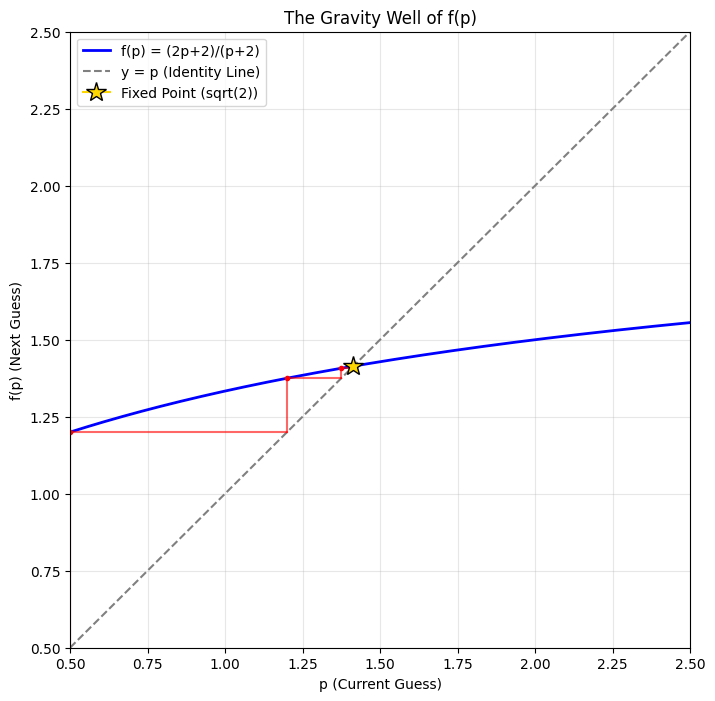

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define our function
def f(p):
    return (2*p + 2) / (p + 2)

# 2. Set up the plotting area (focusing on positive rationals near root 2)
p_vals = np.linspace(0.5, 2.5, 400)
y_vals = f(p_vals)

plt.figure(figsize=(8, 8))
plt.plot(p_vals, y_vals, label="f(p) = (2p+2)/(p+2)", color="blue", linewidth=2)
plt.plot(p_vals, p_vals, label="y = p (Identity Line)", color="gray", linestyle="--")

# 3. Simulate the Fixed-Point Iterations (Cobwebbing)
guess = 0.5  # Start with a terrible guess to see the effect
iterations = 4

# Plot the starting point on the x-axis
plt.plot(guess, 0, marker='o', color='red')
plt.annotate('  Start (p0)', (guess, 0.05))

for i in range(iterations):
    next_guess = f(guess)
    
    # Draw vertical line from (p, p) to (p, f(p))
    plt.plot([guess, guess], [guess, next_guess], color="red", alpha=0.6)
    
    # Draw horizontal line from (p, f(p)) to (f(p), f(p)) on the identity line
    plt.plot([guess, next_guess], [next_guess, next_guess], color="red", alpha=0.6)
    
    plt.plot(guess, next_guess, marker='.', color='red')
    guess = next_guess

# 4. Mark the true square root of 2
true_root = np.sqrt(2)
plt.plot(true_root, true_root, marker='*', color='gold', markersize=15, 
         markeredgecolor='black', label="Fixed Point (sqrt(2))")

# 5. Formatting
plt.title("The Gravity Well of f(p)")
plt.xlabel("p (Current Guess)")
plt.ylabel("f(p) (Next Guess)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0.5, 2.5)
plt.ylim(0.5, 2.5)

plt.show()